<a href="https://colab.research.google.com/github/HARSHUL-1312/Autism-prediction-/blob/main/Autism_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autism Prediction using Machine Learning
This notebook performs data analysis and builds a classification model to predict Autism Spectrum Disorder (ASD) based on screening scores and demographic data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# Configure visual settings for better readability
pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')

## 1. Data Loading and Initial Exploration

In [4]:
df=pd.read_csv('/content/train.csv')

In [5]:
df.shape

(800, 22)

In [6]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [7]:
df.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,0,1,0,0,0,0,0,0,1,...,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,...,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,...,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,...,f,?,no,no,Canada,no,9.069342,18 and more,Self,0
799,800,0,1,0,0,0,0,0,0,0,...,f,?,no,no,United Arab Emirates,yes,2.243304,18 and more,Self,0


In [8]:
pd.set_option('display.max_columns',None)
sns.set_theme(style='darkgrid')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [10]:
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [11]:
df['age']=df['age'].astype(int)

In [12]:
df.head(2)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0


In [13]:
for col in df.columns:
  numerical_features=['ID','age','result']
  if col not in numerical_features:
    print(col,df[col].unique())
    print(".."*50)

A1_Score [1 0]
....................................................................................................
A2_Score [0 1]
....................................................................................................
A3_Score [1 0]
....................................................................................................
A4_Score [0 1]
....................................................................................................
A5_Score [1 0]
....................................................................................................
A6_Score [0 1]
....................................................................................................
A7_Score [1 0]
....................................................................................................
A8_Score [0 1]
....................................................................................................
A9_Score [1 0]
.........................................................

In [14]:
df=df.drop(columns=['ID','age_desc'])

In [15]:
df.shape

(800, 20)

In [16]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,Self,0


## 2. Data Cleaning and Preprocessing
In this section, we handle missing values, map country names for consistency, and simplify the 'relation' and 'ethnicity' categories.

In [17]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [18]:
df['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [19]:
mapping={
    'Viet Nam': 'vietnam',
    'AmericanSamoa':'United States',
    'Hong Kong':'china'
}
df['contry_of_res']=df['contry_of_res'].replace(mapping)

In [20]:
df['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'china', 'Angola',
       'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [21]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [22]:
df.shape

(800, 20)

In [23]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [24]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [25]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


mean:27.96375
median:24.0
std:16.32982746445208


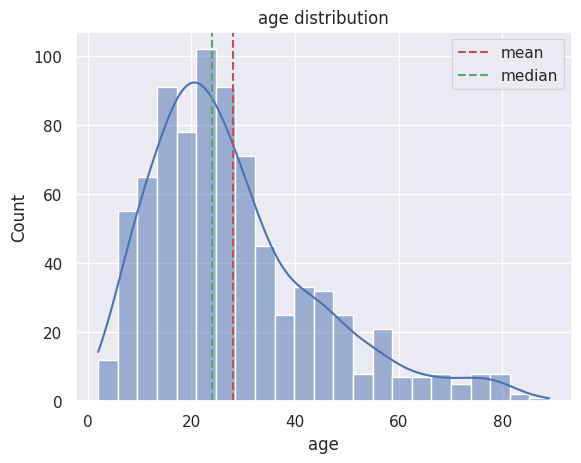

In [26]:
sns.histplot(df['age'],kde=True)
plt.title('age distribution')
age_mean=df['age'].mean()
age_median=df['age'].median()
age_std=df['age'].std()
print(f'mean:{age_mean}')
print(f'median:{age_median}')
print(f'std:{age_std}')
plt.axvline(age_mean,color='r',linestyle='--',label='mean')
plt.axvline(age_median,color='g',linestyle='--',label='median')
plt.legend()
plt.show()

mean:8.537303106501248
median:9.605299308
std:4.8076756865846075


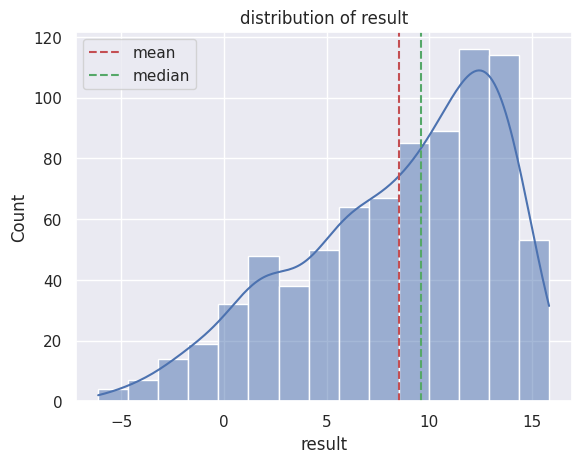

In [27]:
sns.histplot(df['result'],kde=True)
plt.title('distribution of result')
result_mean=df['result'].mean()
result_median=df['result'].median()
result_std=df['result'].std()
print(f'mean:{result_mean}')
print(f'median:{result_median}')
print(f'std:{result_std}')
plt.axvline(result_mean,color='r',linestyle='--',label='mean')
plt.axvline(result_median,color='g',linestyle='--',label='median')
plt.legend()
plt.show()

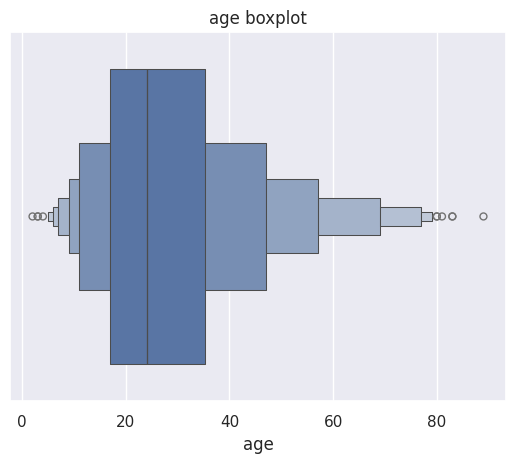

In [28]:
sns.boxenplot(x=df['age'])
plt.title('age boxplot')
plt.xlabel('age')
plt.show()

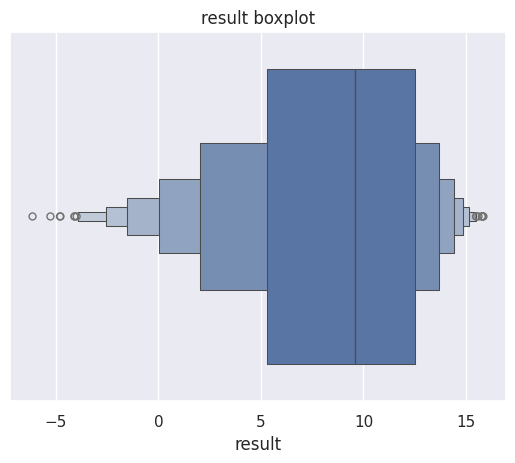

In [29]:
 sns.boxenplot(x=df['result'])
 plt.title('result boxplot')
 plt.xlabel('result')
 plt.show()

In [30]:
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
age_outliers=df[(df['age']<lower_bound) | (df['age']>upper_bound)]
print(age_outliers)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
19          1         1         1         1         1         1         1   
31          0         1         0         0         0         0         0   
33          1         1         1         1         1         1         1   
41          1         1         1         1         1         0         1   
92          0         1         1         1         1         1         0   
93          0         0         0         0         0         0         0   
161         1         1         1         1         1         1         1   
231         1         1         1         1         1         1         1   
238         1         1         1         1         1         0         1   
241         0         0         0         0         0         0         0   
262         1         1         1         1         1         1         1   
264         1         1         1         1         1         1         1   

In [31]:
age_outliers

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
19,1,1,1,1,1,1,1,1,1,1,72,m,White-European,no,yes,United States,yes,12.286905,Self,1
31,0,1,0,0,0,0,0,1,0,0,74,f,Asian,no,no,Jordan,no,2.412387,Self,0
33,1,1,1,1,1,1,1,0,1,1,67,m,White-European,yes,no,New Zealand,no,11.647281,Self,0
41,1,1,1,1,1,0,1,1,1,1,74,m,White-European,no,no,United Kingdom,no,7.387992,Self,0
92,0,1,1,1,1,1,0,1,1,1,75,m,Latino,no,yes,United States,no,6.699799,Self,0
93,0,0,0,0,0,0,0,0,0,0,79,m,?,no,no,India,no,7.813125,Self,0
161,1,1,1,1,1,1,1,1,1,1,79,f,White-European,yes,yes,United States,no,10.482143,Self,0
231,1,1,1,1,1,1,1,1,1,1,69,f,White-European,no,no,United States,no,2.459004,Self,1
238,1,1,1,1,1,0,1,1,1,1,64,f,Latino,yes,no,Australia,no,13.756476,Self,1
241,0,0,0,0,0,0,0,0,1,0,64,f,others,no,no,Jordan,no,2.142376,Self,0


In [32]:
len(age_outliers)

39

In [33]:
Q1=df['result'].quantile(0.25)
Q3=df['result'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
result_outliers=df[(df['result']<lower_bound) | (df['result']>upper_bound)]
print(result_outliers)


     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
698         0         0         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score  age gender ethnicity jaundice austim  \
698         0         0          0   62      f     Asian       no     no   

    contry_of_res used_app_before    result relation  Class/ASD  
698        Jordan              no -6.137748     Self          0  


In [34]:
len(result_outliers)

1

In [35]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

## 3. Exploratory Data Analysis (EDA)
Visualizing the distribution of scores, age, and categorical features to understand the dataset's characteristics.

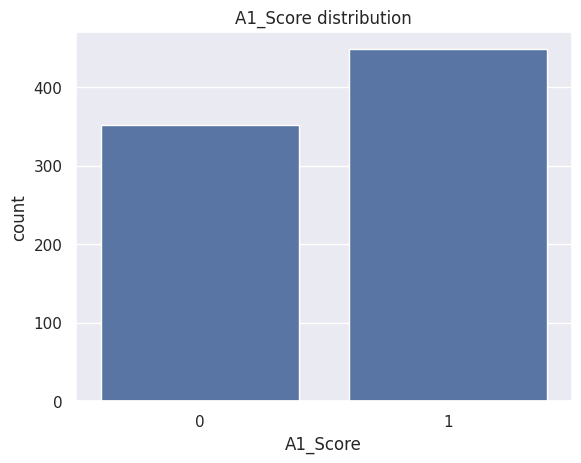

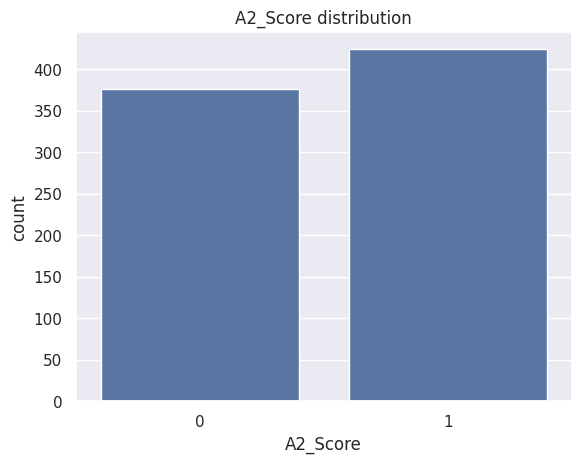

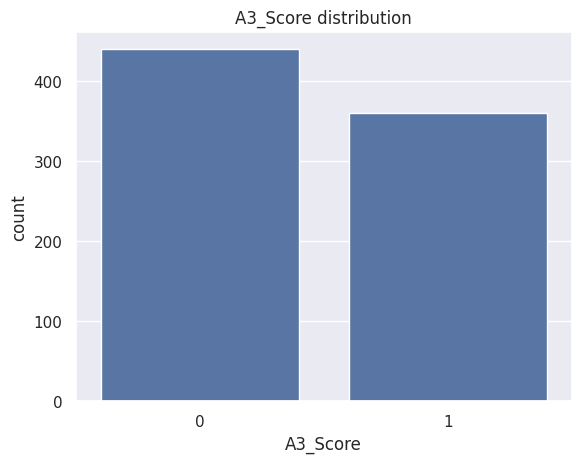

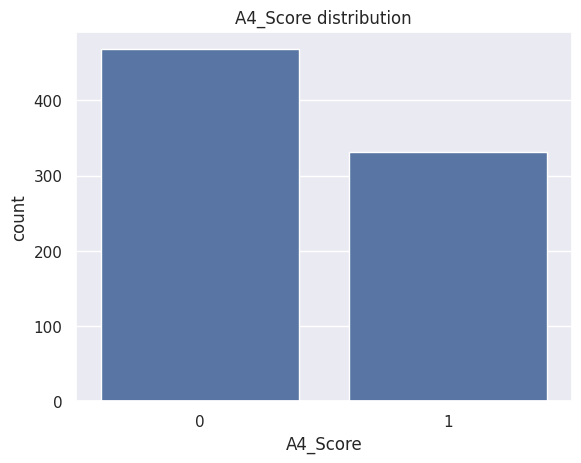

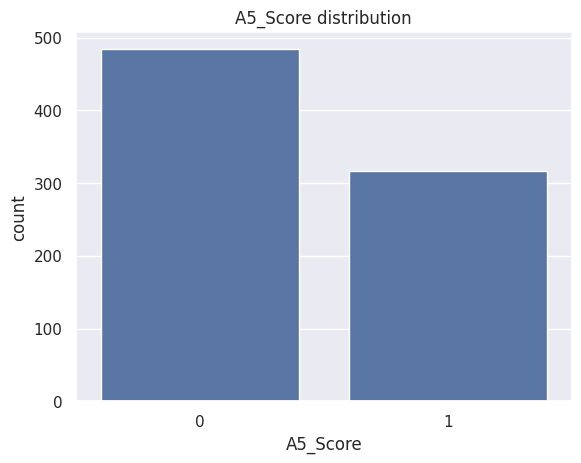

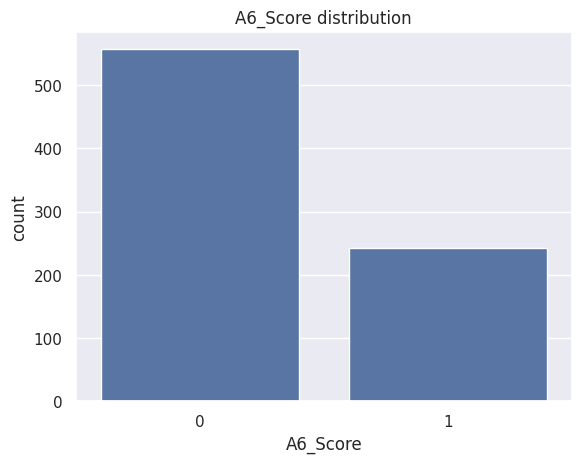

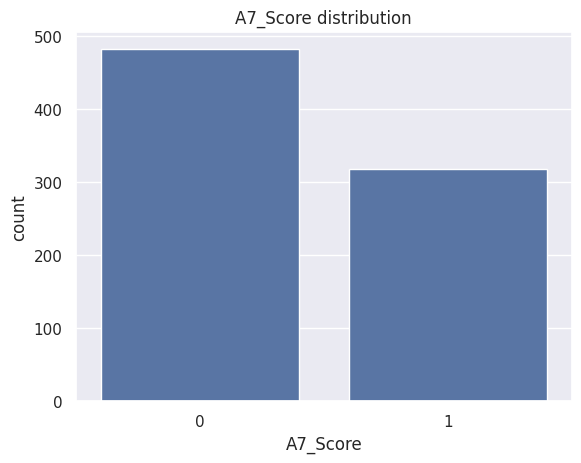

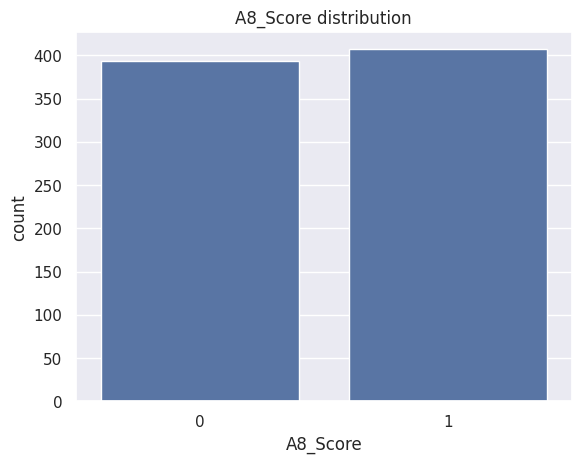

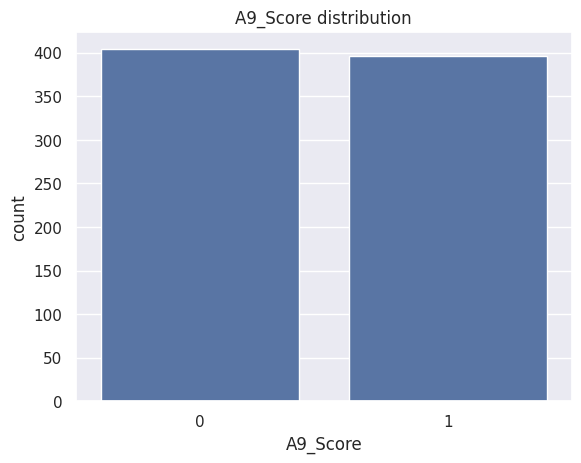

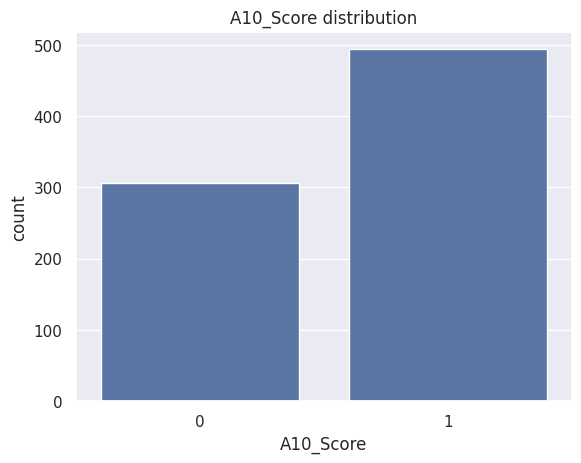

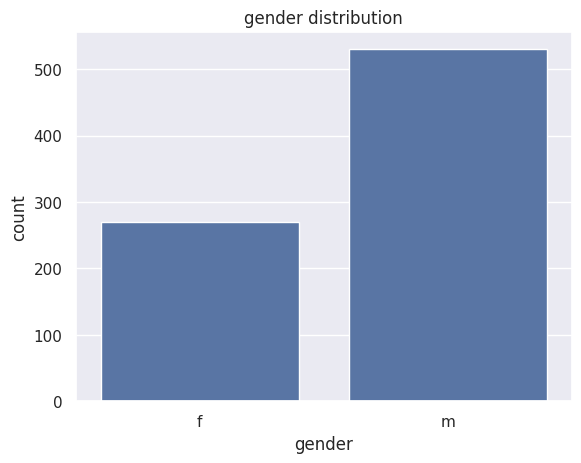

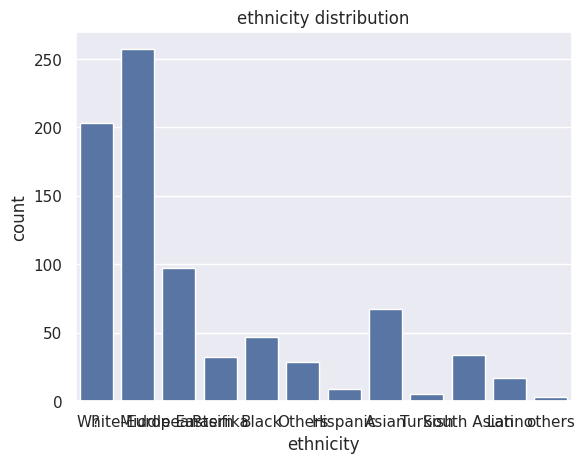

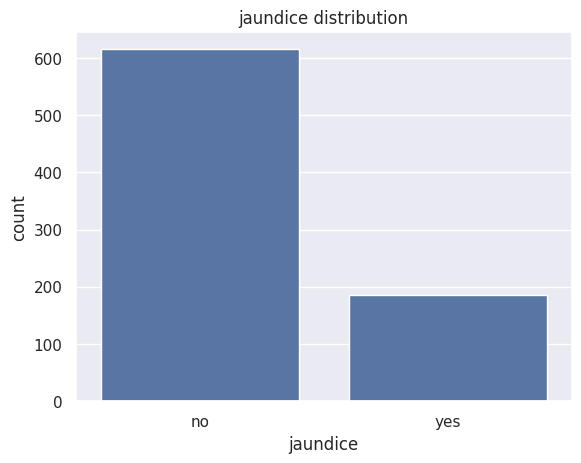

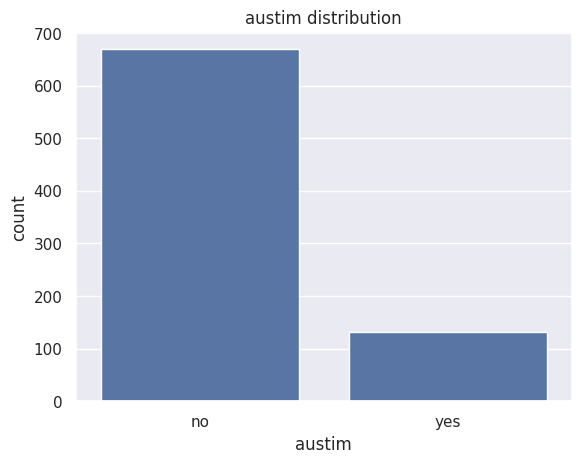

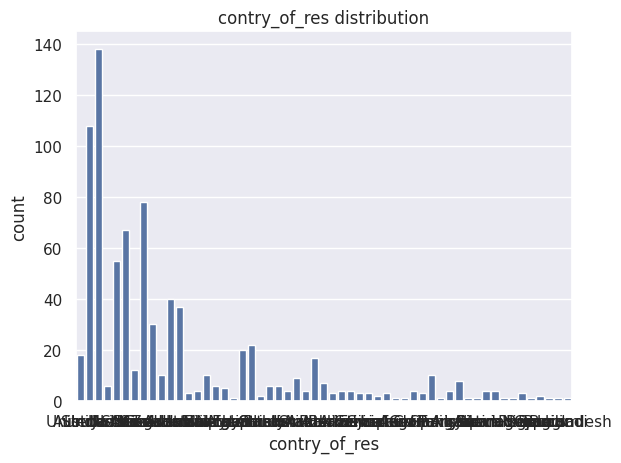

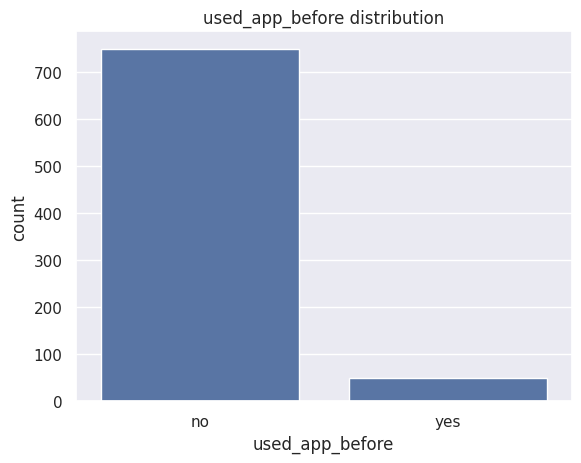

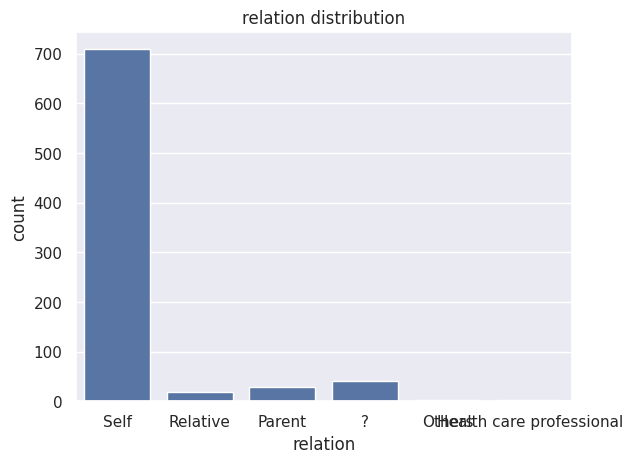

In [36]:
categorical_columns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation']
for col in categorical_columns:
  sns.countplot(x=df[col])
  plt.title(f'{col} distribution')
  plt.xlabel(col)
  plt.ylabel('count')
  plt.show()

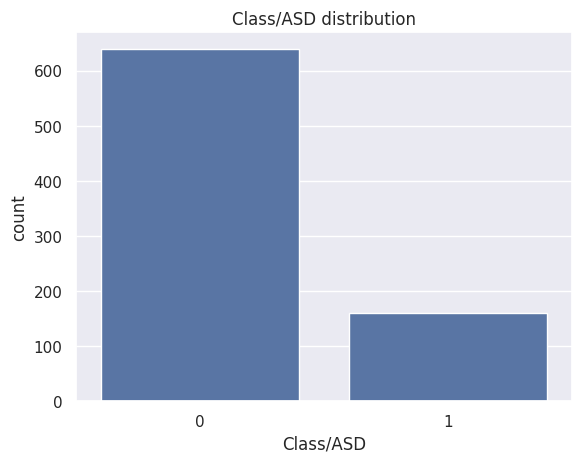

In [37]:
sns.countplot(x=df['Class/ASD'])
plt.title('Class/ASD distribution')
plt.xlabel('Class/ASD')
plt.ylabel('count')
plt.show()

In [38]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [39]:
df['ethnicity']=df['ethnicity'].replace({'others':'Others','?':'Others'})

In [40]:
df['relation'].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [41]:
df['relation']=df['relation'].replace({'?':'Others','Relative':'Others','Parent':'Others','Health care professional':'Others'})

In [42]:
df['relation'].unique()

array(['Self', 'Others'], dtype=object)

In [43]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,Others,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,Others,no,no,India,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,Others,no,no,United States,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,Others,no,no,South Africa,no,-4.777286,Self,0


In [46]:
object_columns =df.select_dtypes(include=['object']).columns

In [47]:
print(object_columns)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')


In [49]:
# Initialize a dictionary to store LabelEncoders for each categorical column
encode = {}
for col in object_columns:
    le = LabelEncoder()
    # Transform string values into numerical labels
    df[col] = le.fit_transform(df[col])
    encode[col] = le

# Save encoders to a file for future inference usage
with open('encode.pkl', 'wb') as f:
    pickle.dump(encode, f)

In [51]:
encode

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

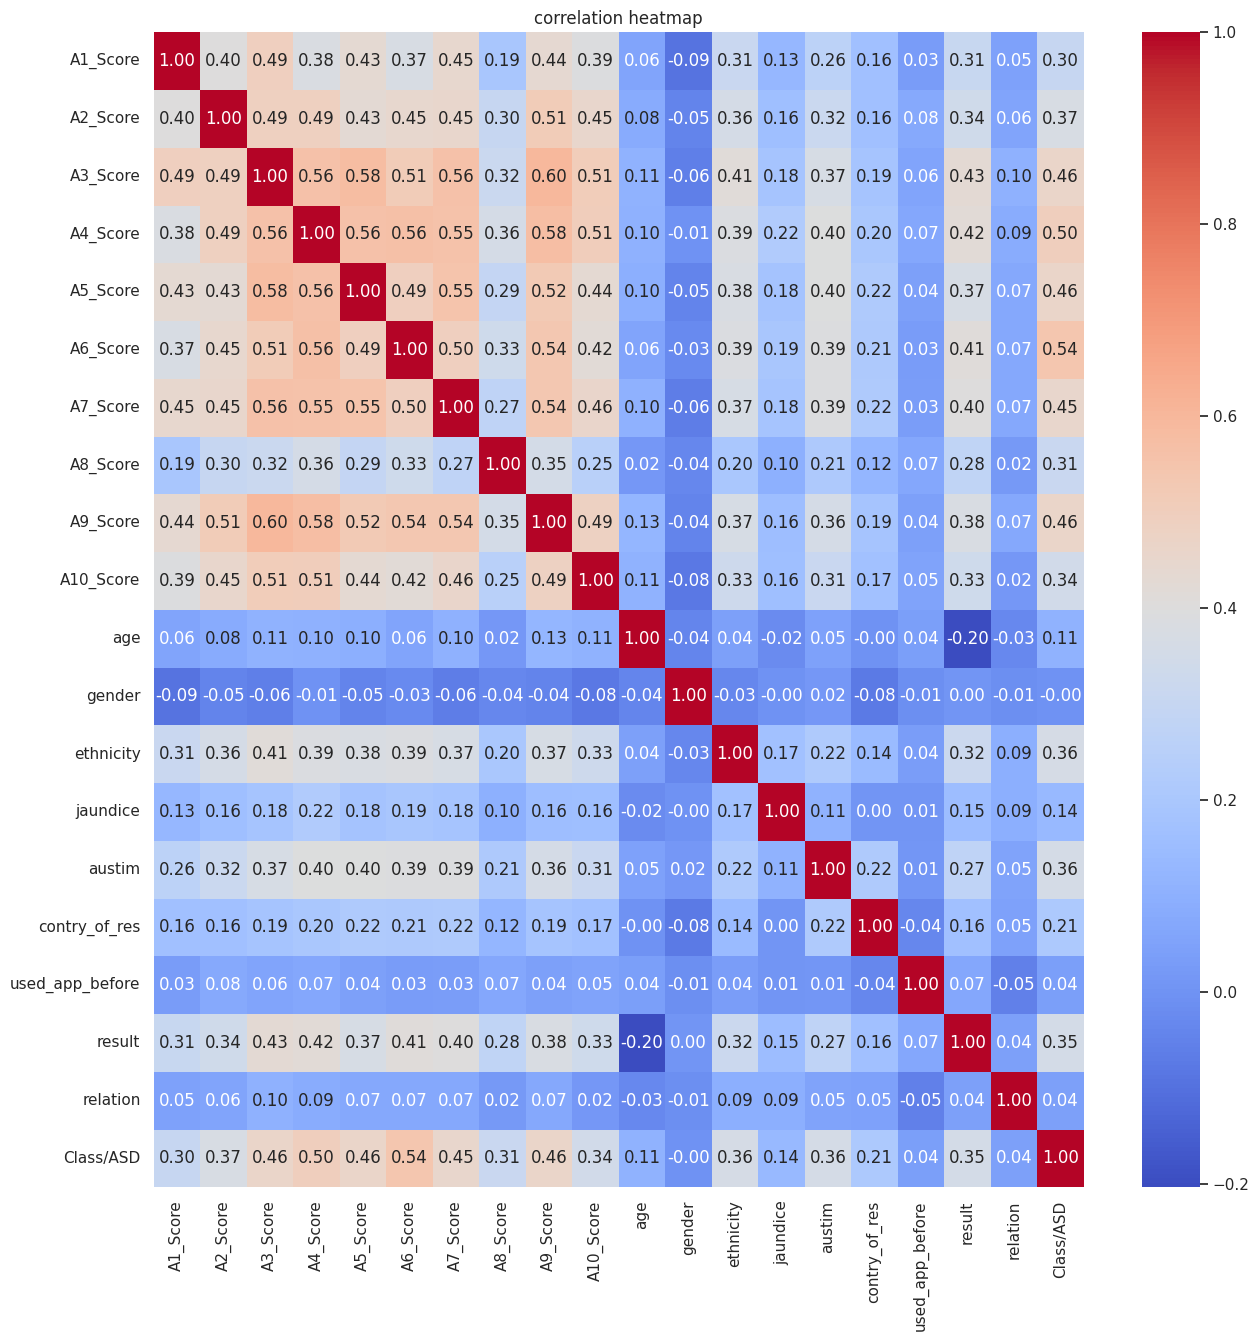

In [53]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap')
plt.show()

## 4. Feature Engineering and Outlier Handling
We replace outliers with medians and encode categorical variables into numerical formats for the machine learning models.

In [54]:
def replace_outlier_with_median(df,column):
  Q1=df[column].quantile(.25)
  Q3=df[column].quantile(.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  median=df[column].median()
  df[column]=df[column].apply(lambda x:median if x<lower_bound or x>upper_bound else x)
  return df

In [55]:
df=replace_outlier_with_median(df,'age')
df=replace_outlier_with_median(df,'result')


In [56]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1,0


In [57]:
df.shape


(800, 20)

In [58]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [59]:
x=df.drop(columns=['Class/ASD'])
y=df['Class/ASD']

## 5. Model Training and Selection
We split the data, handle class imbalance using SMOTE, and perform a hyperparameter search using RandomizedSearchCV across multiple classifiers.

In [60]:
print(x)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0           1         0         1         0         1         0         1   
1           0         0         0         0         0         0         0   
2           1         1         1         1         1         1         1   
3           0         0         0         0         0         0         0   
4           0         0         0         0         0         0         0   
..        ...       ...       ...       ...       ...       ...       ...   
795         0         1         0         0         0         0         0   
796         0         1         1         0         0         1         0   
797         0         0         0         0         0         0         0   
798         0         0         0         0         0         0         0   
799         0         1         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score   age  gender  ethnicity  jaundice  aust

In [61]:
print(y)

0      0
1      0
2      1
3      0
4      0
      ..
795    0
796    0
797    0
798    0
799    0
Name: Class/ASD, Length: 800, dtype: int64


In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [64]:
y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [65]:
y_test.value_counts()

,count
Class/ASD,
0,124
1,36


In [66]:
# Address the class imbalance by generating synthetic samples for the minority class (ASD positive)
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [67]:
print(y_train_resampled.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


In [68]:
print(y_train_resampled.shape)

(1030,)


In [69]:
models={
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'XGBClassifier':XGBClassifier(random_state=42)
}

In [71]:
cv_scores={}
for model_name,model in models.items():
  print(f'training {model_name} with default parameters')
  cv_score=cross_val_score(model,x_train_resampled,y_train_resampled,cv=5,scoring='accuracy')
  cv_scores[model_name]=cv_score
  print(f'{model_name} cross-validation accuracy:{cv_score.mean():.2f}')
  print('..'*50)

training DecisionTreeClassifier with default parameters
DecisionTreeClassifier cross-validation accuracy:0.85
....................................................................................................
training RandomForestClassifier with default parameters
RandomForestClassifier cross-validation accuracy:0.92
....................................................................................................
training XGBClassifier with default parameters
XGBClassifier cross-validation accuracy:0.90
....................................................................................................


In [72]:
cv_scores

{'DecisionTreeClassifier': array([0.7961165 , 0.86893204, 0.87378641, 0.8592233 , 0.86893204]),
 'RandomForestClassifier': array([0.91747573, 0.91747573, 0.9223301 , 0.91747573, 0.9223301 ]),
 'XGBClassifier': array([0.8592233 , 0.91747573, 0.90776699, 0.91262136, 0.91262136])}

In [73]:
decision_tree_classifier=DecisionTreeClassifier(random_state=42)
random_forest_classifier=RandomForestClassifier(random_state=42)
xgb_classifier=XGBClassifier(random_state=42)

In [75]:
param_grid_decision_tree={
    'criterion':['gini','entropy'],
    'max_depth':[None,0,20,30,50,70],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
param_grid_random_forest={
    'n_estimators':[50,100,200,500],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'bootstrap':[True,False]
}
param_grid_xgb={
    'n_estimators':[50,100,200,500],
    'max_depth':[3,5,7,10],
    'learning_rate':[0.01,0.1,0.2,0.3],
    'subsample':[0.5,0.7,1.0],
    'colsample_bytree':[0.5,0.7,1.0]
}


In [76]:
random_search_dt=RandomizedSearchCV(estimator=decision_tree_classifier,param_distributions=param_grid_decision_tree,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_search_rf=RandomizedSearchCV(estimator=random_forest_classifier,param_distributions=param_grid_random_forest,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_search_xgb=RandomizedSearchCV(estimator=xgb_classifier,param_distributions=param_grid_xgb,n_iter=10,cv=5,scoring='accuracy',random_state=42)

In [77]:
random_search_dt.fit(x_train_resampled,y_train_resampled)
random_search_rf.fit(x_train_resampled,y_train_resampled)
random_search_xgb.fit(x_train_resampled,y_train_resampled)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_par

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [81]:
print(random_search_dt.best_estimator_)
print(random_search_rf.best_estimator_)
print(random_search_xgb.best_estimator_)
print(random_search_dt.best_score_)
print(random_search_rf.best_score_)
print(random_search_xgb.best_score_)

DecisionTreeClassifier(max_depth=70, random_state=42)
RandomForestClassifier(bootstrap=False, max_depth=10, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)
0.8533980582524272
0.9233009708737864
0.9116504854368932


In [83]:
best_model=None
best_score=0
if random_search_dt.best_score_>best_score:
  best_model=random_search_dt
  best_score=random_search_dt.best_score_
if random_search_rf.best_score_>best_score:
  best_model=random_search_rf
  best_score=random_search_rf.best_score_
if random_search_xgb.best_score_>best_score:
  best_model=random_search_xgb
  best_score=random_search_xgb.best_score_

In [84]:
print(f'best model:{best_model}')
print(f'best cross validation accuracy:{best_score:.2f}')

best model:RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 500]},
                   random_state=42, scoring='accuracy')
best cross validation accuracy:0.92


In [85]:
with open ('best_model.pkl','wb') as f:
  pickle.dump(best_model,f)

In [87]:
y_test_pred=best_model.predict(x_test)
print('accuracy score\n',accuracy_score(y_test,y_test_pred))
print('confusion matrix\n',confusion_matrix(y_test,y_test_pred))
print('classification report\n',classification_report(y_test,y_test_pred))


accuracy score
 0.84375
confusion matrix
 [[109  15]
 [ 10  26]]
classification report
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       124
           1       0.63      0.72      0.68        36

    accuracy                           0.84       160
   macro avg       0.78      0.80      0.79       160
weighted avg       0.85      0.84      0.85       160



## 6. Advanced Modeling: Ensemble Learning
To further improve performance, we implement feature interactions and a Voting Classifier to ensemble the top models.

In [88]:
# Feature Engineering: Enhancing the model by adding derived features
x_train_enhanced = x_train_resampled.copy()
x_test_enhanced = x_test.copy()

# 1. Interaction Feature: Captures the joint effect of age and screening result
x_train_enhanced['age_result_inter'] = x_train_enhanced['age'] * x_train_enhanced['result']
x_test_enhanced['age_result_inter'] = x_test_enhanced['age'] * x_test_enhanced['result']

# 2. Polynomial Feature: Helps capture non-linear relationships for the screening result
x_train_enhanced['result_sq'] = x_train_enhanced['result'] ** 2
x_test_enhanced['result_sq'] = x_test_enhanced['result'] ** 2

display(x_train_enhanced.head())

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,age_result_inter,result_sq
0,1,1,1,1,1,1,1,1,1,1,24.0,1,9,0,1,14,0,12.473339,1,299.360130,155.584180
1,0,0,0,0,0,0,1,1,0,0,9.0,1,1,0,0,34,0,12.647150,0,113.824351,159.950407
2,1,0,0,0,0,0,0,0,0,0,31.0,1,5,0,0,29,0,5.312815,1,164.697270,28.226005
3,0,0,0,0,0,0,0,0,0,0,29.0,1,5,0,0,50,0,8.097968,1,234.841082,65.577092
4,1,1,0,1,0,0,0,0,1,1,30.0,0,9,0,0,14,0,13.940095,1,418.202838,194.326237


In [89]:
# Retrieve the best estimators found during RandomizedSearchCV
dt_best = random_search_dt.best_estimator_
rf_best = random_search_rf.best_estimator_
xgb_best = random_search_xgb.best_estimator_

# Create a Soft Voting Classifier to ensemble predictions across multiple models
voting_clf = VotingClassifier(
    estimators=[
        ('dt', dt_best),
        ('rf', rf_best),
        ('xgb', xgb_best)
    ],
    voting='soft' # Averaging the probabilities predicted by each model
)

voting_clf.fit(x_train_enhanced, y_train_resampled)

# Evaluate the final ensemble model
y_pred_voting = voting_clf.predict(x_test_enhanced)
print('--- Ensemble Model Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_voting))

--- Ensemble Model Performance ---
Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86       124
           1       0.53      0.56      0.54        36

    accuracy                           0.79       160
   macro avg       0.70      0.71      0.70       160
weighted avg       0.79      0.79      0.79       160



## 7. Error Analysis and Visualization
Identifying and visualizing patterns in samples where the model predicted incorrectly.

In [90]:
error_analysis_df = x_test_enhanced.copy()
error_analysis_df['Actual'] = y_test.values
error_analysis_df['Predicted'] = y_pred_voting


misclassified = error_analysis_df[error_analysis_df['Actual'] != error_analysis_df['Predicted']]

print(f"Total misclassified samples: {len(misclassified)}")

display(misclassified.head(10))

Total misclassified samples: 34


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,age_result_inter,result_sq,Actual,Predicted
65,0,1,1,1,1,1,1,0,1,1,38.0,0,9,1,1,37,0,13.067098,1,496.549741,170.749062,1,0
67,1,1,1,1,1,1,1,1,1,1,17.0,1,9,0,0,54,0,3.971814,1,67.520830,15.775302,1,0
377,1,1,1,1,1,0,1,0,1,1,11.0,0,4,0,0,52,0,10.672868,1,117.401547,113.910109,1,0
360,1,1,1,1,1,1,1,1,1,1,15.0,1,9,1,1,52,0,15.474665,1,232.119970,239.465247,0,1
30,1,1,1,1,0,0,0,0,1,1,30.0,1,9,0,0,31,0,13.189531,1,395.685942,173.963738,1,0
23,1,1,1,0,1,1,1,1,1,1,21.0,1,9,0,1,52,0,13.686719,1,287.421105,187.326284,0,1
741,0,0,1,1,1,0,1,1,1,1,21.0,0,9,0,1,46,0,8.867226,1,186.211744,78.627695,0,1
139,1,1,1,1,1,1,1,1,1,1,49.0,1,9,1,0,34,1,6.062900,1,297.082105,36.758758,1,0
174,1,0,1,0,0,0,1,1,1,1,19.0,1,7,0,0,20,0,3.127276,1,59.418253,9.779858,1,0
423,1,1,1,1,1,1,1,1,1,1,23.0,1,9,1,1,51,0,9.691085,1,222.894948,93.917123,1,0


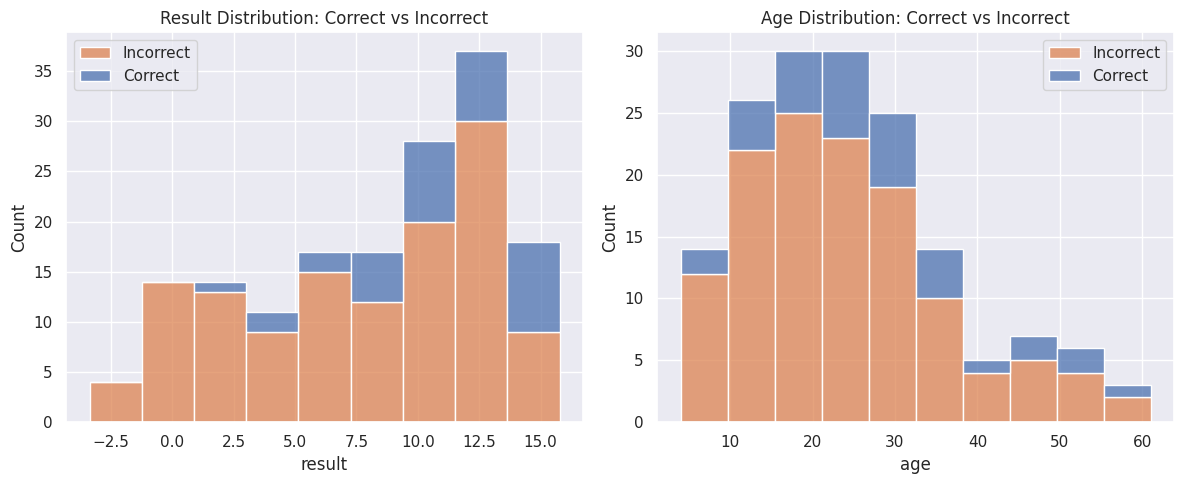

In [91]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=error_analysis_df, x='result', hue=(error_analysis_df['Actual'] == error_analysis_df['Predicted']), multiple="stack")
plt.title('Result Distribution: Correct vs Incorrect')
plt.legend(['Incorrect', 'Correct'])

plt.subplot(1, 2, 2)
sns.histplot(data=error_analysis_df, x='age', hue=(error_analysis_df['Actual'] == error_analysis_df['Predicted']), multiple="stack")
plt.title('Age Distribution: Correct vs Incorrect')
plt.legend(['Incorrect', 'Correct'])

plt.tight_layout()
plt.show()

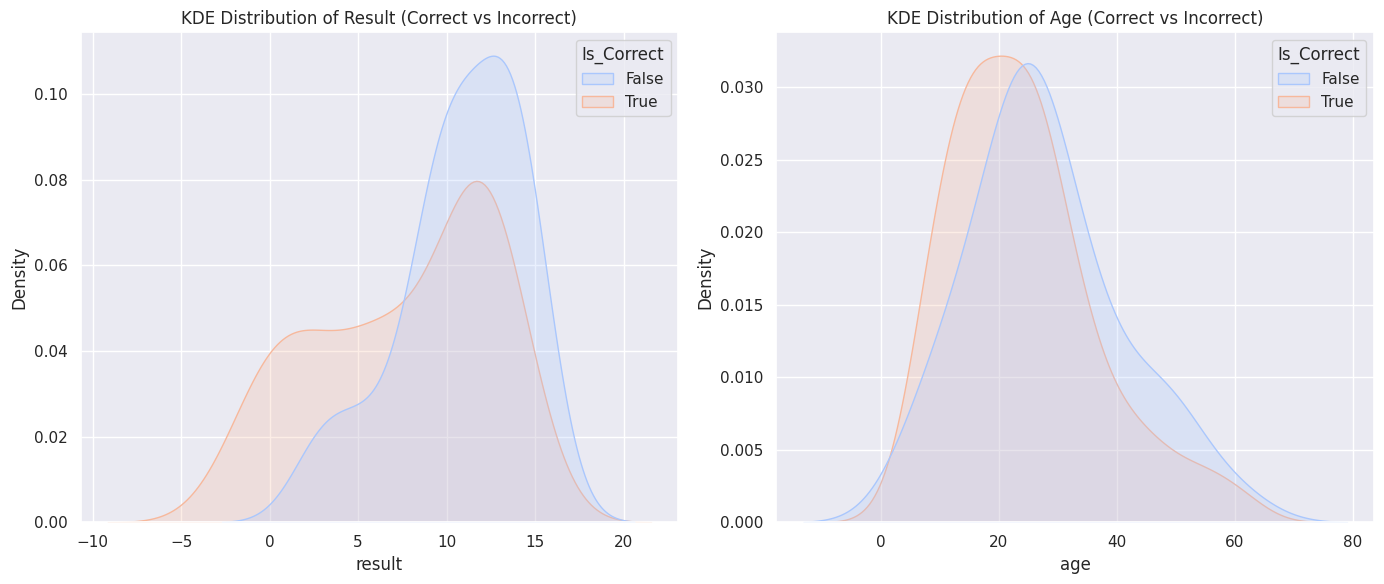

In [92]:
error_analysis_df['Is_Correct'] = error_analysis_df['Actual'] == error_analysis_df['Predicted']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=error_analysis_df, x='result', hue='Is_Correct', fill=True, common_norm=False, palette='coolwarm')
plt.title('KDE Distribution of Result (Correct vs Incorrect)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=error_analysis_df, x='age', hue='Is_Correct', fill=True, common_norm=False, palette='coolwarm')
plt.title('KDE Distribution of Age (Correct vs Incorrect)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1004/422415183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_analysis_df, x='Is_Correct', y='result', palette='Set2')
/tmp/ipykernel_1004/422415183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_analysis_df, x='Is_Correct', y='age', palette='Set2')


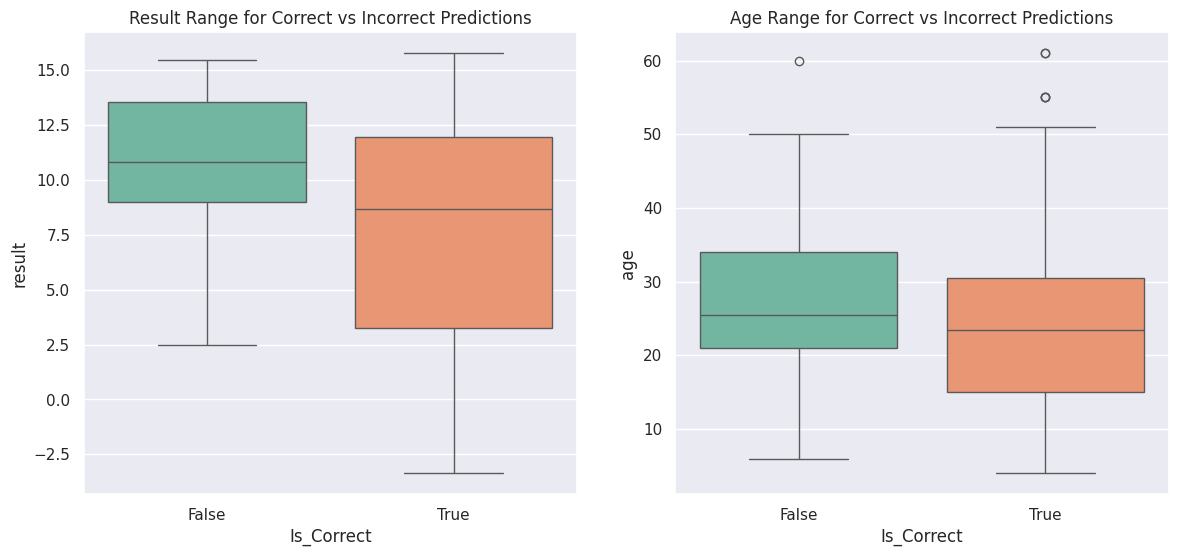

In [93]:

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=error_analysis_df, x='Is_Correct', y='result', palette='Set2')
plt.title('Result Range for Correct vs Incorrect Predictions')

plt.subplot(1, 2, 2)
sns.boxplot(data=error_analysis_df, x='Is_Correct', y='age', palette='Set2')
plt.title('Age Range for Correct vs Incorrect Predictions')

plt.show()